# ECG5000 Anomaly Detection: Controlled Conv1D vs LSTM Autoencoders

**Course project notebook — designed for Google Colab**

This notebook detects anomalous ECG beats using reconstruction error. ECG5000 class **1** is treated as normal; classes **2–5** are anomalous. Both autoencoders are trained **only on normal training beats**.

## Hypothesis and original contribution
The controlled experiment asks whether a Conv1D autoencoder, whose local filters encode short waveform motifs, provides a better speed/quality trade-off than an LSTM autoencoder, whose recurrence models ordered temporal context. The comparison holds the data split, normalization, training-only-on-normal protocol, optimizer family, reconstruction loss, early stopping policy, scoring rule, and threshold-calibration data fixed.

The required original contribution is this controlled **Conv1D AE vs LSTM AE** comparison. A second methodological contribution is an explicit comparison of two justified thresholds: (1) the 95th percentile of reconstruction error on normal-only validation data, and (2) an F1-optimized threshold selected on a separate labeled calibration subset. An untouched stratified final test set is used exactly once for final reporting. Stretch baselines (One-Class SVM and Isolation Forest) provide non-neural reference points.

> **No numerical outcome is asserted in advance.** Run all cells top-to-bottom; the generated tables and figures provide the evidence needed for the discussion.

In [ ]:
!pip install aeon

In [ ]:
# Reproducible, reasonably fast Colab configuration
import pandas as pd

import os, sys, json, random, shutil, warnings, time
from pathlib import Path


import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score, balanced_accuracy_score)
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

import aeon
from aeon.datasets import load_classification


FAST_MODE = False  # False = longer training and larger models
SEED = 42
OUTPUT_DIR = Path('/content/ecg_ae_outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
MODEL_DIR = OUTPUT_DIR / 'models'
for directory in (OUTPUT_DIR, FIG_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print('Deterministic-op request was not available:', exc)

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))
print('FAST_MODE:', FAST_MODE, '| output:', OUTPUT_DIR)

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
FAST_MODE: False | output: /content/ecg_ae_outputs


## Methodology and leakage controls

1. Combine the archive's original train/test files, then create a reproducible **stratified final test split** (20%) that is not used for model selection or threshold calibration. This makes the evaluation protocol explicit and independent of the archive's historical split.
2. Split the remaining development data into a **labeled calibration subset** and a model-development subset, both stratified by the original five classes.
3. From model-development data, retain normal class-1 beats only, then split those into normal training and normal validation sets.
4. Fit feature-wise standardization **only on normal training beats**; transform every other split using those frozen statistics.
5. Train each autoencoder only on normalized normal training beats. Early stopping observes only normal-validation reconstruction loss.
6. Select thresholds without final-test access: a normal-validation 95th percentile, and a labeled-calibration F1 optimum.
7. Freeze models and thresholds, then report final-test results.

The labeled calibration threshold is expected to target empirical F1 more directly, while the normal-only threshold is usable when labeled anomalies are unavailable. Comparing both exposes that practical trade-off.

In [ ]:
# Load both official ECG5000 splits through aeon (no Kaggle key required).
X, y, meta_data = load_classification(
    'ECG5000',
    split=None,
    return_metadata=True,
)

print('Shape of X =', X.shape)
print('Shape of y =', y.shape)
print('Meta data =', meta_data)

# Labels arrive as strings in some aeon versions; use integer class IDs.
y_class = y.astype(int)
# aeon uses (samples, channels, timesteps); ECG5000 is univariate.
X_raw = X.squeeze(axis=1).astype('float32')

assert X_raw.shape[1] == 140 and set(np.unique(y_class)) == {1, 2, 3, 4, 5}
print('Loaded:', X_raw.shape, '| class labels:', np.unique(y_class))


Shape of X = (5000, 1, 140)
Shape of y = (5000,)
Meta data = {'problemname': 'ecg5000', 'timestamps': False, 'missing': False, 'univariate': True, 'equallength': True, 'classlabel': True, 'targetlabel': False, 'class_values': ['1', '2', '3', '4', '5']}
Loaded: (5000, 140) | class labels: [1 2 3 4 5]


,class,count,name,percent
0,1,2919,Normal,58.38
1,2,1767,R-on-T PVC,35.34
2,3,96,PVC,1.92
3,4,194,SP/EB,3.88
4,5,24,Unclassified,0.48


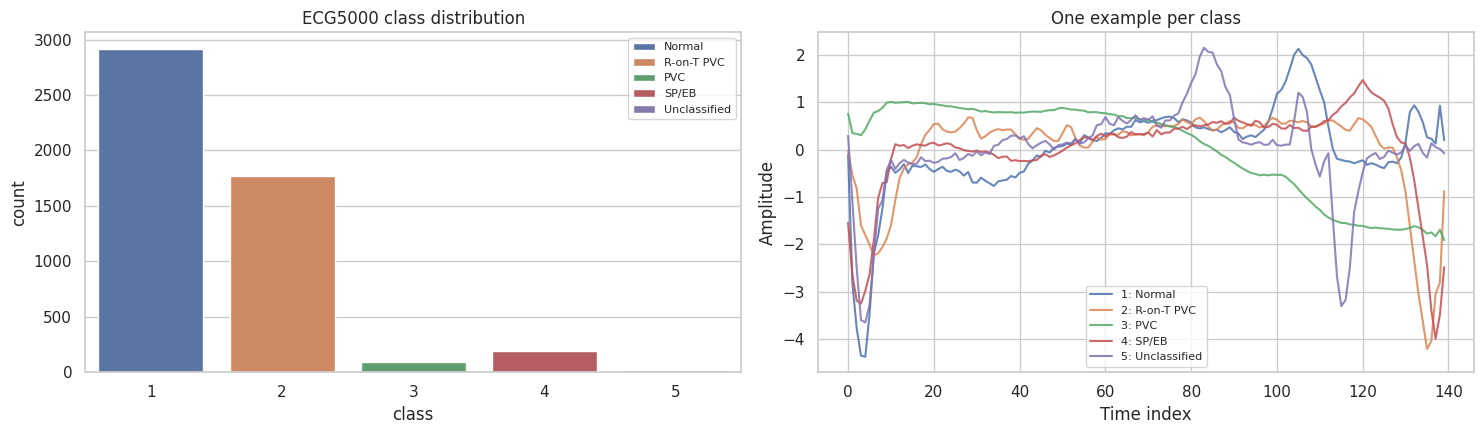

In [ ]:
# EDA: class distribution and representative waveforms
class_names = {1: 'Normal', 2: 'R-on-T PVC', 3: 'PVC', 4: 'SP/EB', 5: 'Unclassified'}
counts = pd.Series(y_class).value_counts().sort_index().rename_axis('class').reset_index(name='count')
counts['name'] = counts['class'].map(class_names)
counts['percent'] = 100 * counts['count'] / counts['count'].sum()
display(counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(data=counts, x='class', y='count', hue='name', dodge=False, ax=axes[0])
axes[0].set_title('ECG5000 class distribution'); axes[0].legend(fontsize=8)
for cls in sorted(class_names):
    idx = np.flatnonzero(y_class == cls)[0]
    axes[1].plot(X_raw[idx], label=f'{cls}: {class_names[cls]}', alpha=.85)
axes[1].set(title='One example per class', xlabel='Time index', ylabel='Amplitude')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / 'eda_distribution_waveforms.png', dpi=160, bbox_inches='tight'); plt.show()


In [ ]:
# Leakage-safe split: final test first, then labeled calibration, then normal-only train/validation
all_idx = np.arange(len(X_raw))
dev_idx, final_idx = train_test_split(
    all_idx, test_size=0.20, random_state=SEED, stratify=y_class)
model_dev_idx, calib_idx = train_test_split(
    dev_idx, test_size=0.20, random_state=SEED + 1, stratify=y_class[dev_idx])
normal_dev_idx = model_dev_idx[y_class[model_dev_idx] == 1]
normal_train_idx, normal_val_idx = train_test_split(
    normal_dev_idx, test_size=0.20, random_state=SEED + 2)

# Fit preprocessing exclusively on normal training beats. Each time position is a feature.
scaler = StandardScaler().fit(X_raw[normal_train_idx])
X_train_n = scaler.transform(X_raw[normal_train_idx]).astype(np.float32)
X_val_n = scaler.transform(X_raw[normal_val_idx]).astype(np.float32)
X_calib = scaler.transform(X_raw[calib_idx]).astype(np.float32)
X_final = scaler.transform(X_raw[final_idx]).astype(np.float32)
y_calib = (y_class[calib_idx] != 1).astype(int)
y_final = (y_class[final_idx] != 1).astype(int)
class_final = y_class[final_idx]

assert not (set(normal_train_idx) & set(normal_val_idx) | set(dev_idx) & set(final_idx))
assert np.all(y_class[normal_train_idx] == 1) and np.all(y_class[normal_val_idx] == 1)
split_rows = []
for name, idx in [('normal_train', normal_train_idx), ('normal_val', normal_val_idx),
                  ('labeled_calibration', calib_idx), ('untouched_final_test', final_idx)]:
    row = {'split': name, 'n': len(idx), 'normal': int(np.sum(y_class[idx] == 1)),
           'anomaly': int(np.sum(y_class[idx] != 1)),
           'class_1': int(np.sum(y_class[idx] == 1)),
           'class_2': int(np.sum(y_class[idx] == 2)),
           'class_3': int(np.sum(y_class[idx] == 3)),
           'class_4': int(np.sum(y_class[idx] == 4)),
           'class_5': int(np.sum(y_class[idx] == 5))}
    split_rows.append(row)
split_table = pd.DataFrame(split_rows)
display(split_table)
split_table.to_csv(OUTPUT_DIR / 'split_summary.csv', index=False)
print('Final test remains untouched until the evaluation cells below.')


,split,n,normal,anomaly,class_1,class_2,class_3,class_4,class_5
0,normal_train,1494,1494,0,1494,0,0,0,0
1,normal_val,374,374,0,374,0,0,0,0
2,labeled_calibration,800,467,333,467,283,15,31,4
3,untouched_final_test,1000,584,416,584,353,19,39,5


Final test remains untouched until the evaluation cells below.


## Autoencoder architectures

Both models receive `(140, 1)` beats and minimize mean squared reconstruction error. The Conv1D model compresses local patterns through strided pooling; the LSTM model compresses the full sequence into a recurrent latent vector. `FAST_MODE=True` keeps default Colab runtime practical. Parameter counts and exact layer summaries below make model capacity differences transparent rather than implying the models are perfectly parameter-matched.

In [ ]:
X_train_seq = X_train_n[..., None]
X_val_seq = X_val_n[..., None]
X_calib_seq = X_calib[..., None]
X_final_seq = X_final[..., None]
INPUT_SHAPE = (X_train_seq.shape[1], 1)

def build_conv_ae():
    filters = (16, 8) if FAST_MODE else (32, 16)
    inputs = tf.keras.Input(shape=INPUT_SHAPE, name='ecg')
    x = tf.keras.layers.Conv1D(filters[0], 7, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling1D(2, padding='same')(x)
    x = tf.keras.layers.Conv1D(filters[1], 5, padding='same', activation='relu')(x)
    encoded = tf.keras.layers.MaxPooling1D(2, padding='same', name='latent_sequence')(x)
    x = tf.keras.layers.Conv1D(filters[1], 5, padding='same', activation='relu')(encoded)
    x = tf.keras.layers.UpSampling1D(2)(x)
    x = tf.keras.layers.Conv1D(filters[0], 7, padding='same', activation='relu')(x)
    x = tf.keras.layers.UpSampling1D(2)(x)
    outputs = tf.keras.layers.Conv1D(1, 3, padding='same', name='reconstruction')(x)
    model = tf.keras.Model(inputs, outputs, name='Conv1D_AE')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
    return model

def build_lstm_ae():
    units = 24 if FAST_MODE else 48
    inputs = tf.keras.Input(shape=INPUT_SHAPE, name='ecg')
    encoded = tf.keras.layers.LSTM(units, name='latent_vector')(inputs)
    x = tf.keras.layers.RepeatVector(INPUT_SHAPE[0])(encoded)
    x = tf.keras.layers.LSTM(units, return_sequences=True)(x)
    outputs = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1), name='reconstruction')(x)
    model = tf.keras.Model(inputs, outputs, name='LSTM_AE')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
    return model

models = {'Conv1D_AE': build_conv_ae(), 'LSTM_AE': build_lstm_ae()}
for name, model in models.items():
    print(f'\n{name}: {model.count_params():,} parameters')
    model.summary()



Conv1D_AE: 7,841 parameters


Model: "Conv1D_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg (InputLayer)                │ (None, 140, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 140, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 70, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 70, 16)         │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_sequence (MaxPooling1D)  │ (None, 35, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 35, 16)         │         1,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 70, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 70, 32)         │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_3 (UpSampling1D)  │ (None, 140, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv1D)         │ (None, 140, 1)         │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,841 (30.63 KB)

 Trainable params: 7,841 (30.63 KB)

...

Model: "LSTM_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg (InputLayer)                │ (None, 140, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (LSTM)            │ (None, 48)             │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 140, 48)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 140, 48)        │        18,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 140, 1)         │            49 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,273 (110.44 KB)

 Trainable params: 28,273 (110.44 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
24/24 - 2s - 100ms/step - loss: 0.5184 - val_loss: 0.1839 - learning_rate: 0.0010
Epoch 2/60
24/24 - 0s - 13ms/step - loss: 0.1676 - val_loss: 0.1073 - learning_rate: 0.0010
Epoch 3/60
24/24 - 0s - 13ms/step - loss: 0.1078 - val_loss: 0.0775 - learning_rate: 0.0010
Epoch 4/60
24/24 - 0s - 13ms/step - loss: 0.0878 - val_loss: 0.0670 - learning_rate: 0.0010
Epoch 5/60
24/24 - 0s - 13ms/step - loss: 0.0776 - val_loss: 0.0593 - learning_rate: 0.0010
Epoch 6/60
24/24 - 0s - 13ms/step - loss: 0.0702 - val_loss: 0.0543 - learning_rate: 0.0010
Epoch 7/60
24/24 - 0s - 13ms/step - loss: 0.0648 - val_loss: 0.0506 - learning_rate: 0.0010
Epoch 8/60
24/24 - 0s - 12ms/step - loss: 0.0611 - val_loss: 0.0480 - learning_rate: 0.0010
Epoch 9/60
24/24 - 0s - 13ms/step - loss: 0.0583 - val_loss: 0.0461 - learning_rate: 0.0010
Epoch 10/60
24/24 - 0s - 13ms/step - loss: 0.0561 - val_loss: 0.0444 - learning_rate: 0.0010
Epoch 11/60
24/24 - 0s - 13ms/step - loss: 0.0542 - val_loss: 0.0431 - learnin

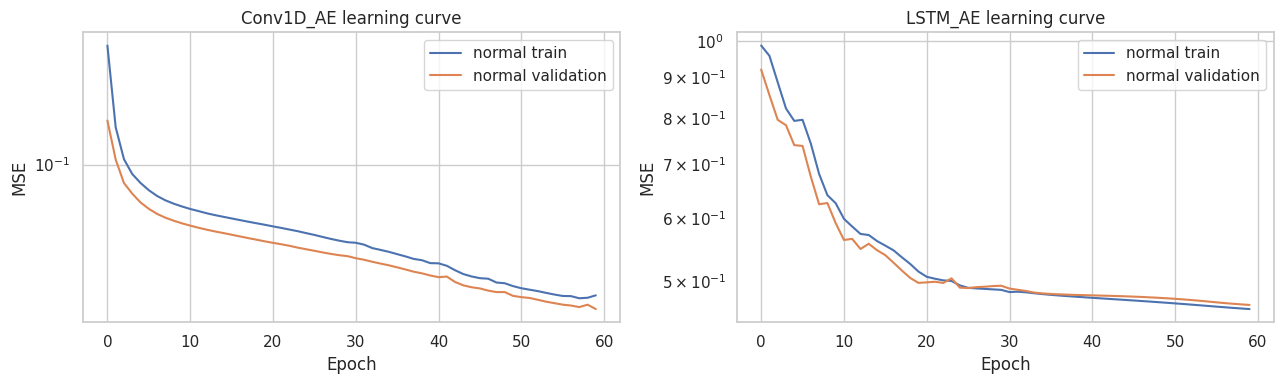

In [ ]:
# Train only on normal beats; checkpoint best normal-validation loss
EPOCHS = 20 if FAST_MODE else 60
BATCH_SIZE = 128 if FAST_MODE else 64
PATIENCE = 4 if FAST_MODE else 8
histories, train_seconds = {}, {}

for name, model in models.items():
    checkpoint = MODEL_DIR / f'{name}_best.keras'
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE,
                                         restore_best_weights=True, min_delta=1e-5),
        tf.keras.callbacks.ModelCheckpoint(checkpoint, monitor='val_loss',
                                           save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=.5,
                                             patience=max(2, PATIENCE // 2), min_lr=1e-5),
    ]
    started = time.perf_counter()
    histories[name] = model.fit(
        X_train_seq, X_train_seq, validation_data=(X_val_seq, X_val_seq),
        epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, callbacks=callbacks, verbose=2)
    train_seconds[name] = time.perf_counter() - started
    models[name] = tf.keras.models.load_model(checkpoint)
    models[name].save(MODEL_DIR / f'{name}_final.keras')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, history) in zip(axes, histories.items()):
    ax.plot(history.history['loss'], label='normal train')
    ax.plot(history.history['val_loss'], label='normal validation')
    ax.set(title=f'{name} learning curve', xlabel='Epoch', ylabel='MSE', yscale='log')
    ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / 'training_curves.png', dpi=160, bbox_inches='tight'); plt.show()


## Reconstruction scoring and threshold calibration

Each score is the mean squared reconstruction error across all 140 time points. Two thresholds are estimated separately for each model:

- **Normal-validation P95:** the 95th percentile of scores from held-out normal beats. This uses no anomaly labels and nominally allows about 5% of comparable normal validation beats above threshold, though distribution shift can change the final-test false-positive rate.
- **Labeled-calibration F1 optimum:** the threshold maximizing F1 on the separate labeled calibration split. This is appropriate when representative labeled anomalies exist, but can overfit the calibration prevalence and anomaly mix.

Neither rule accesses the final-test labels or scores during selection.

In [ ]:
def reconstruction_mse(model, X):
    reconstructed = model.predict(X, batch_size=256, verbose=0)
    return np.mean(np.square(X.squeeze(-1) - reconstructed.squeeze(-1)), axis=1)

def f1_optimal_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    best = int(np.nanargmax(f1))
    return float(thresholds[best]), float(f1[best])

scores = {}
thresholds = {}
for name, model in models.items():
    scores[name] = {
        'normal_val': reconstruction_mse(model, X_val_seq),
        'calibration': reconstruction_mse(model, X_calib_seq),
        'final': reconstruction_mse(model, X_final_seq),
    }
    p95 = float(np.percentile(scores[name]['normal_val'], 95))
    f1_thr, calib_f1 = f1_optimal_threshold(y_calib, scores[name]['calibration'])
    thresholds[name] = {'normal_val_p95': p95, 'calibration_f1': f1_thr}
    print(name, thresholds[name], '| best calibration F1:', round(calib_f1, 4))

with open(OUTPUT_DIR / 'thresholds.json', 'w') as handle:
    json.dump(thresholds, handle, indent=2)


Conv1D_AE {'normal_val_p95': 0.028793131932616234, 'calibration_f1': 0.014834936708211899} | best calibration F1: 0.8159
LSTM_AE {'normal_val_p95': 1.1901949644088745, 'calibration_f1': 1.5235207080841064} | best calibration F1: 0.9514


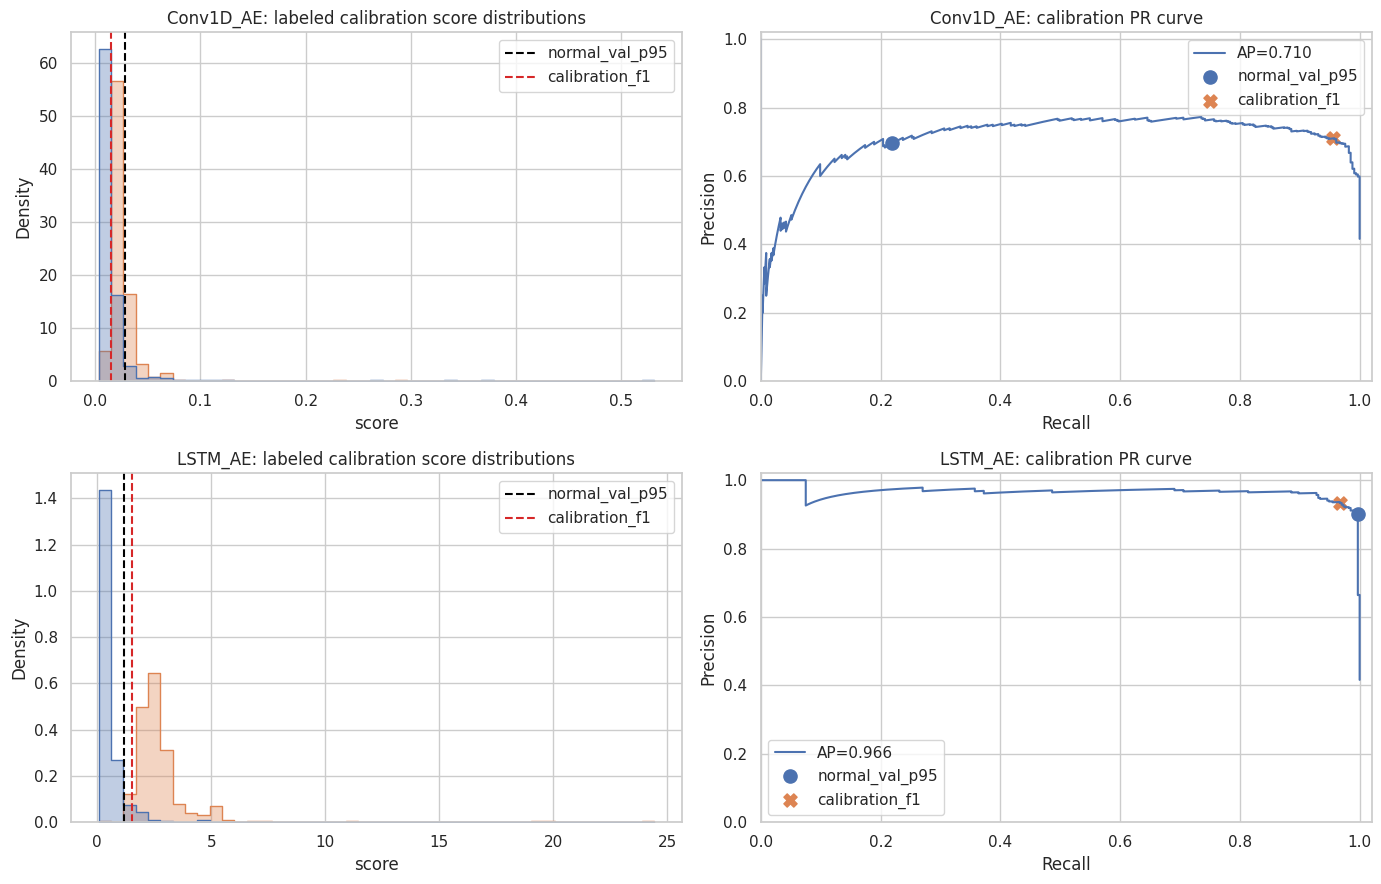

In [ ]:
# Threshold calibration plots (calibration labels only; final test is not shown here)
fig, axes = plt.subplots(len(models), 2, figsize=(14, 4.5 * len(models)))
for row, name in enumerate(models):
    ax = axes[row, 0]
    plot_df = pd.DataFrame({'score': scores[name]['calibration'],
                            'label': np.where(y_calib == 1, 'Anomaly', 'Normal')})
    sns.histplot(data=plot_df, x='score', hue='label', bins=45, stat='density',
                 common_norm=False, element='step', fill=True, alpha=.35, ax=ax)
    for key, color in [('normal_val_p95', 'black'), ('calibration_f1', 'tab:red')]:
        ax.axvline(thresholds[name][key], color=color, linestyle='--', label=key)
    ax.set_title(f'{name}: labeled calibration score distributions'); ax.legend()

    p, r, t = precision_recall_curve(y_calib, scores[name]['calibration'])
    axes[row, 1].plot(r, p, label=f'AP={average_precision_score(y_calib, scores[name]["calibration"]):.3f}')
    for key, marker in [('normal_val_p95', 'o'), ('calibration_f1', 'X')]:
        pred = scores[name]['calibration'] > thresholds[name][key]
        axes[row, 1].scatter(recall_score(y_calib, pred), precision_score(y_calib, pred, zero_division=0),
                             s=90, marker=marker, label=key)
    axes[row, 1].set(title=f'{name}: calibration PR curve', xlabel='Recall', ylabel='Precision',
                     xlim=(0, 1.02), ylim=(0, 1.02)); axes[row, 1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR / 'threshold_calibration.png', dpi=160, bbox_inches='tight'); plt.show()


## Untouched final-test evaluation

The following cells are the first place final-test labels are used. Precision, recall, F1, confusion matrices, PR curves, error distributions, and anomaly-type breakdowns are all computed from the same frozen final subset.

In [ ]:
def metric_row(model_name, threshold_name, y_true, model_scores, threshold):
    pred = (model_scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {'model': model_name, 'threshold_rule': threshold_name, 'threshold': threshold,
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'specificity': tn / (tn + fp) if (tn + fp) else np.nan,
            'balanced_accuracy': balanced_accuracy_score(y_true, pred),
            'f1': f1_score(y_true, pred, zero_division=0),
            'average_precision': average_precision_score(y_true, model_scores),
            'roc_auc': roc_auc_score(y_true, model_scores),
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

result_rows = []
for name in models:
    for threshold_name, threshold in thresholds[name].items():
        result_rows.append(metric_row(name, threshold_name, y_final, scores[name]['final'], threshold))
results = pd.DataFrame(result_rows).sort_values(['threshold_rule', 'f1'], ascending=[True, False])
display(results.round(4))
results.to_csv(OUTPUT_DIR / 'autoencoder_final_metrics.csv', index=False)


,model,threshold_rule,threshold,precision,recall,specificity,balanced_accuracy,f1,average_precision,roc_auc,tn,fp,fn,tp
3,LSTM_AE,calibration_f1,1.5235,0.9666,0.9736,0.9760,0.9748,0.9701,0.9616,0.9877,570,14,11,405
1,Conv1D_AE,calibration_f1,0.0148,0.7151,0.9591,0.7277,0.8434,0.8193,0.7141,0.8773,425,159,17,399
2,LSTM_AE,normal_val_p95,1.1902,0.9367,0.9952,0.9521,0.9736,0.9650,0.9616,0.9877,556,28,2,414
0,Conv1D_AE,normal_val_p95,0.0288,0.7174,0.2380,0.9332,0.5856,0.3574,0.7141,0.8773,545,39,317,99


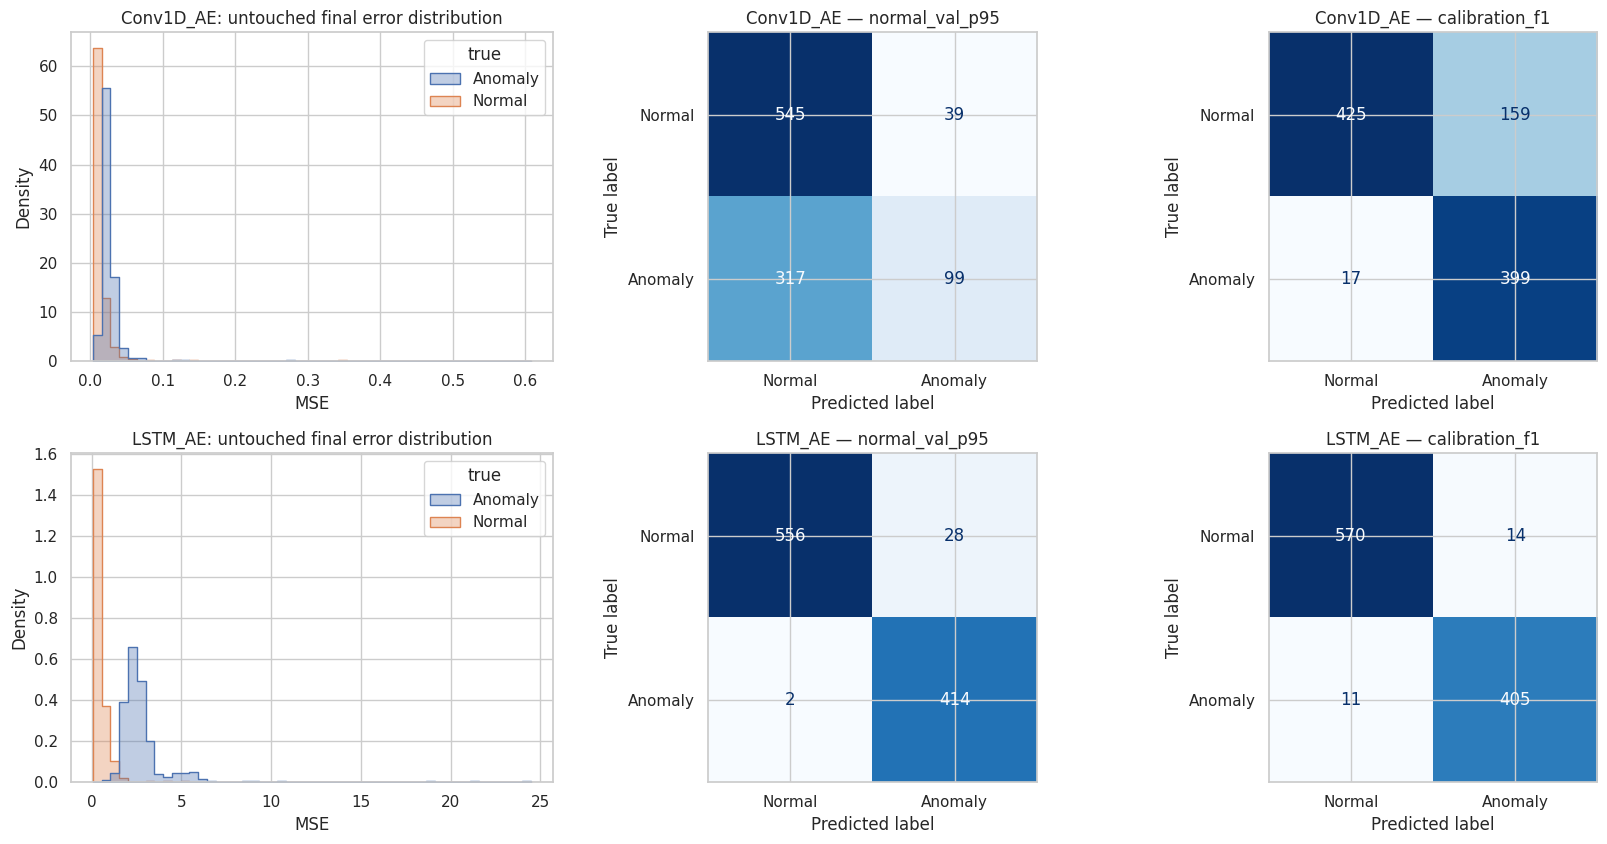

In [ ]:
# Final normal-vs-anomaly error distributions and confusion matrices
fig, axes = plt.subplots(len(models), 3, figsize=(17, 4.3 * len(models)))
for row, name in enumerate(models):
    final_plot = pd.DataFrame({'MSE': scores[name]['final'],
                               'true': np.where(y_final == 1, 'Anomaly', 'Normal')})
    sns.histplot(data=final_plot, x='MSE', hue='true', bins=50, stat='density',
                 common_norm=False, element='step', alpha=.35, ax=axes[row, 0])
    axes[row, 0].set_title(f'{name}: untouched final error distribution')
    for col, rule in enumerate(['normal_val_p95', 'calibration_f1'], start=1):
        pred = (scores[name]['final'] > thresholds[name][rule]).astype(int)
        ConfusionMatrixDisplay.from_predictions(y_final, pred, labels=[0, 1],
            display_labels=['Normal', 'Anomaly'], cmap='Blues', colorbar=False, ax=axes[row, col])
        axes[row, col].set_title(f'{name} — {rule}')
plt.tight_layout(); plt.savefig(FIG_DIR / 'final_distributions_confusions.png', dpi=160, bbox_inches='tight'); plt.show()


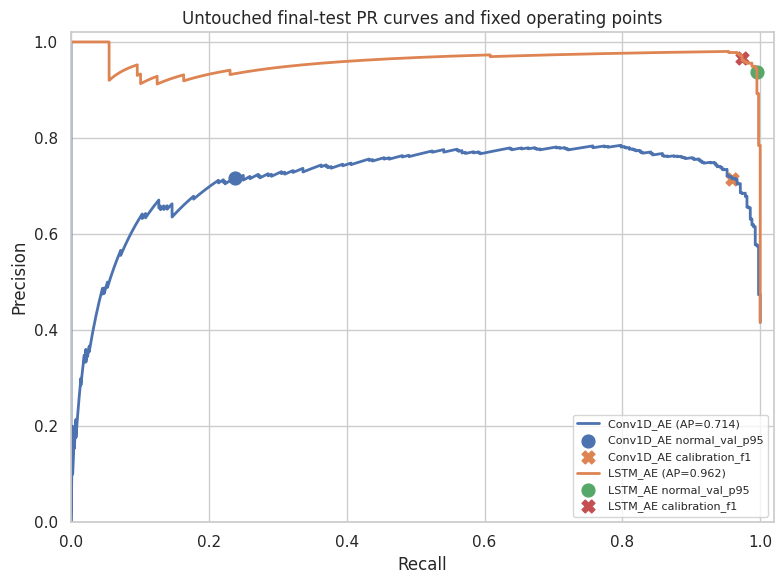

In [ ]:
# Final-test precision-recall curves; operating points were fixed on non-test data
plt.figure(figsize=(8, 6))
for name in models:
    p, r, _ = precision_recall_curve(y_final, scores[name]['final'])
    ap = average_precision_score(y_final, scores[name]['final'])
    plt.plot(r, p, linewidth=2, label=f'{name} (AP={ap:.3f})')
    for rule, marker in [('normal_val_p95', 'o'), ('calibration_f1', 'X')]:
        pred = scores[name]['final'] > thresholds[name][rule]
        plt.scatter(recall_score(y_final, pred), precision_score(y_final, pred, zero_division=0),
                    marker=marker, s=85, label=f'{name} {rule}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Untouched final-test PR curves and fixed operating points')
plt.xlim(0, 1.02); plt.ylim(0, 1.02); plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(FIG_DIR / 'final_pr_curves.png', dpi=160, bbox_inches='tight'); plt.show()


,model,threshold_rule,class,anomaly_type,support,detected,recall
0,Conv1D_AE,normal_val_p95,2,R-on-T PVC,353,79,0.2238
1,Conv1D_AE,normal_val_p95,3,PVC,19,7,0.3684
2,Conv1D_AE,normal_val_p95,4,SP/EB,39,10,0.2564
3,Conv1D_AE,normal_val_p95,5,Unclassified,5,3,0.6000
4,Conv1D_AE,calibration_f1,2,R-on-T PVC,353,342,0.9688
5,Conv1D_AE,calibration_f1,3,PVC,19,18,0.9474
6,Conv1D_AE,calibration_f1,4,SP/EB,39,34,0.8718
7,Conv1D_AE,calibration_f1,5,Unclassified,5,5,1.0000
8,LSTM_AE,normal_val_p95,2,R-on-T PVC,353,352,0.9972
9,LSTM_AE,normal_val_p95,3,PVC,19,18,0.9474


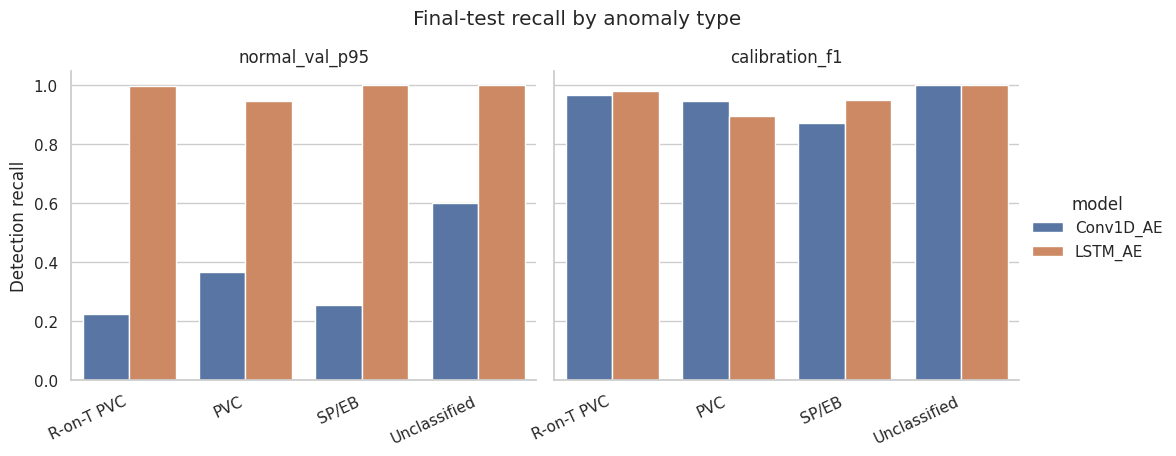

In [ ]:
# Per-anomaly-type detection results at both preselected thresholds
type_rows = []
for name in models:
    for rule, threshold in thresholds[name].items():
        pred = scores[name]['final'] > threshold
        for cls in range(2, 6):
            mask = class_final == cls
            type_rows.append({'model': name, 'threshold_rule': rule, 'class': cls,
                              'anomaly_type': class_names[cls], 'support': int(mask.sum()),
                              'detected': int(pred[mask].sum()),
                              'recall': float(pred[mask].mean()) if mask.any() else np.nan})
per_type = pd.DataFrame(type_rows)
display(per_type.round(4))
per_type.to_csv(OUTPUT_DIR / 'per_anomaly_type_results.csv', index=False)

g = sns.catplot(data=per_type, x='anomaly_type', y='recall', hue='model',
                col='threshold_rule', kind='bar', height=4.2, aspect=1.25)
g.set_xticklabels(rotation=25, ha='right'); g.set_axis_labels('', 'Detection recall')
g.set_titles('{col_name}'); g.fig.suptitle('Final-test recall by anomaly type', y=1.05)
g.savefig(FIG_DIR / 'per_anomaly_type_recall.png', dpi=160, bbox_inches='tight'); plt.show()


## Failure-case inspection

False positives reveal normal morphology the detector reconstructs poorly; false negatives reveal anomalies it reconstructs too well. The plot uses the labeled-calibration threshold because that rule explicitly optimizes the project's requested F1 objective. If fewer than three errors of a kind occur, all available examples are shown.

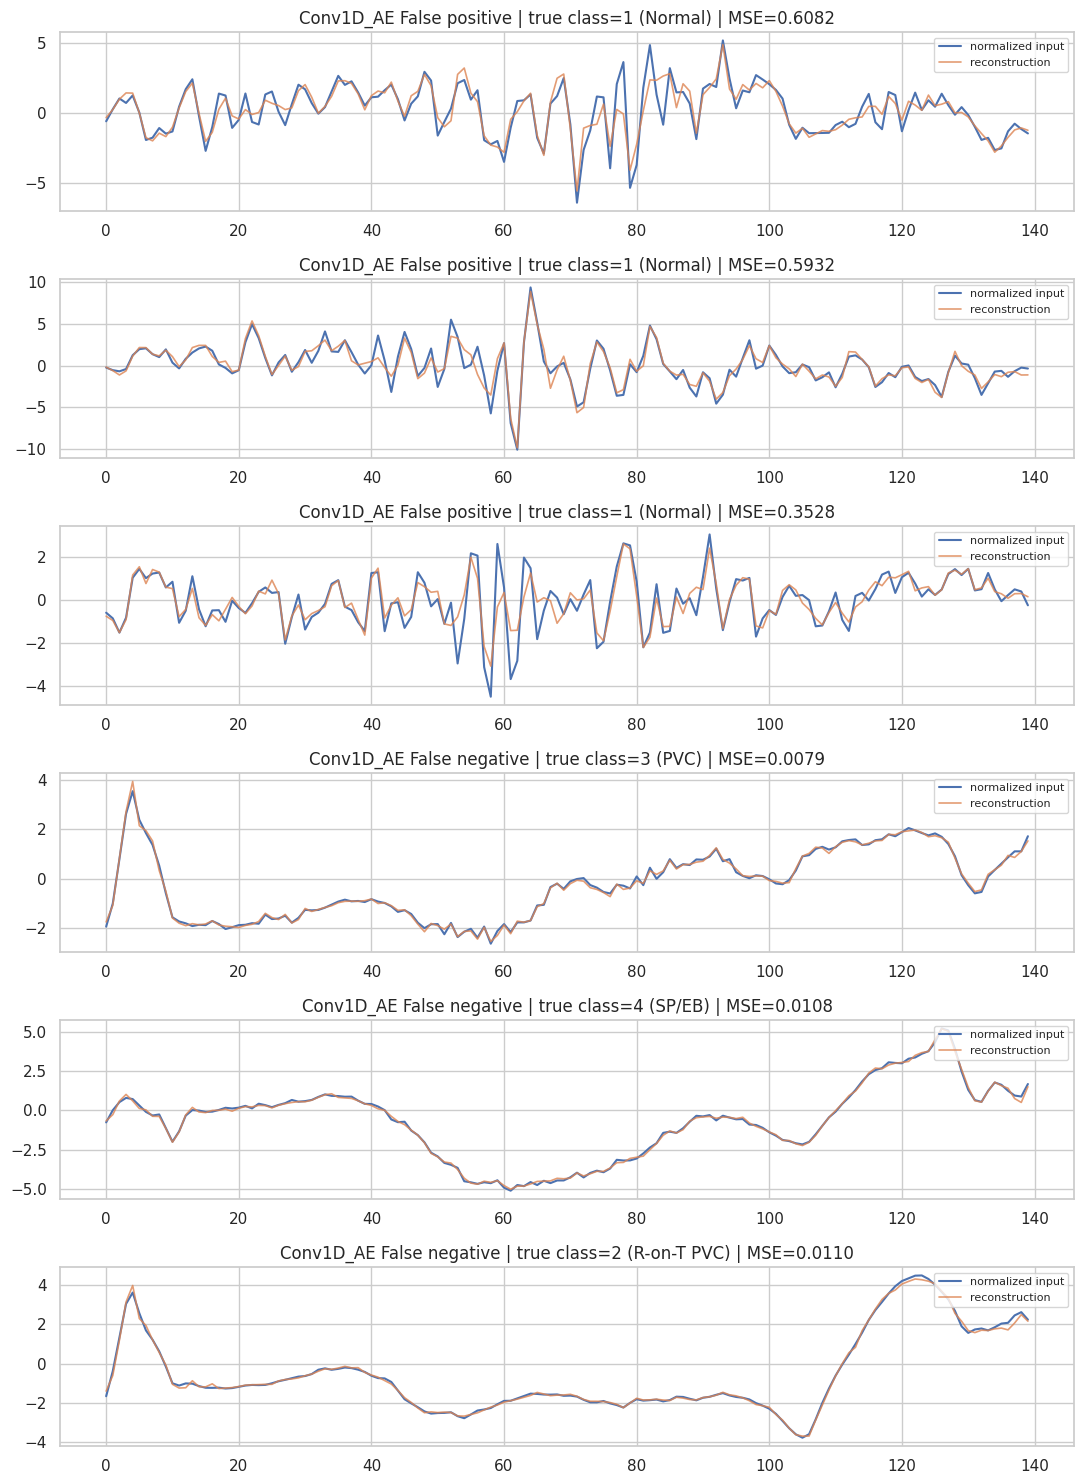

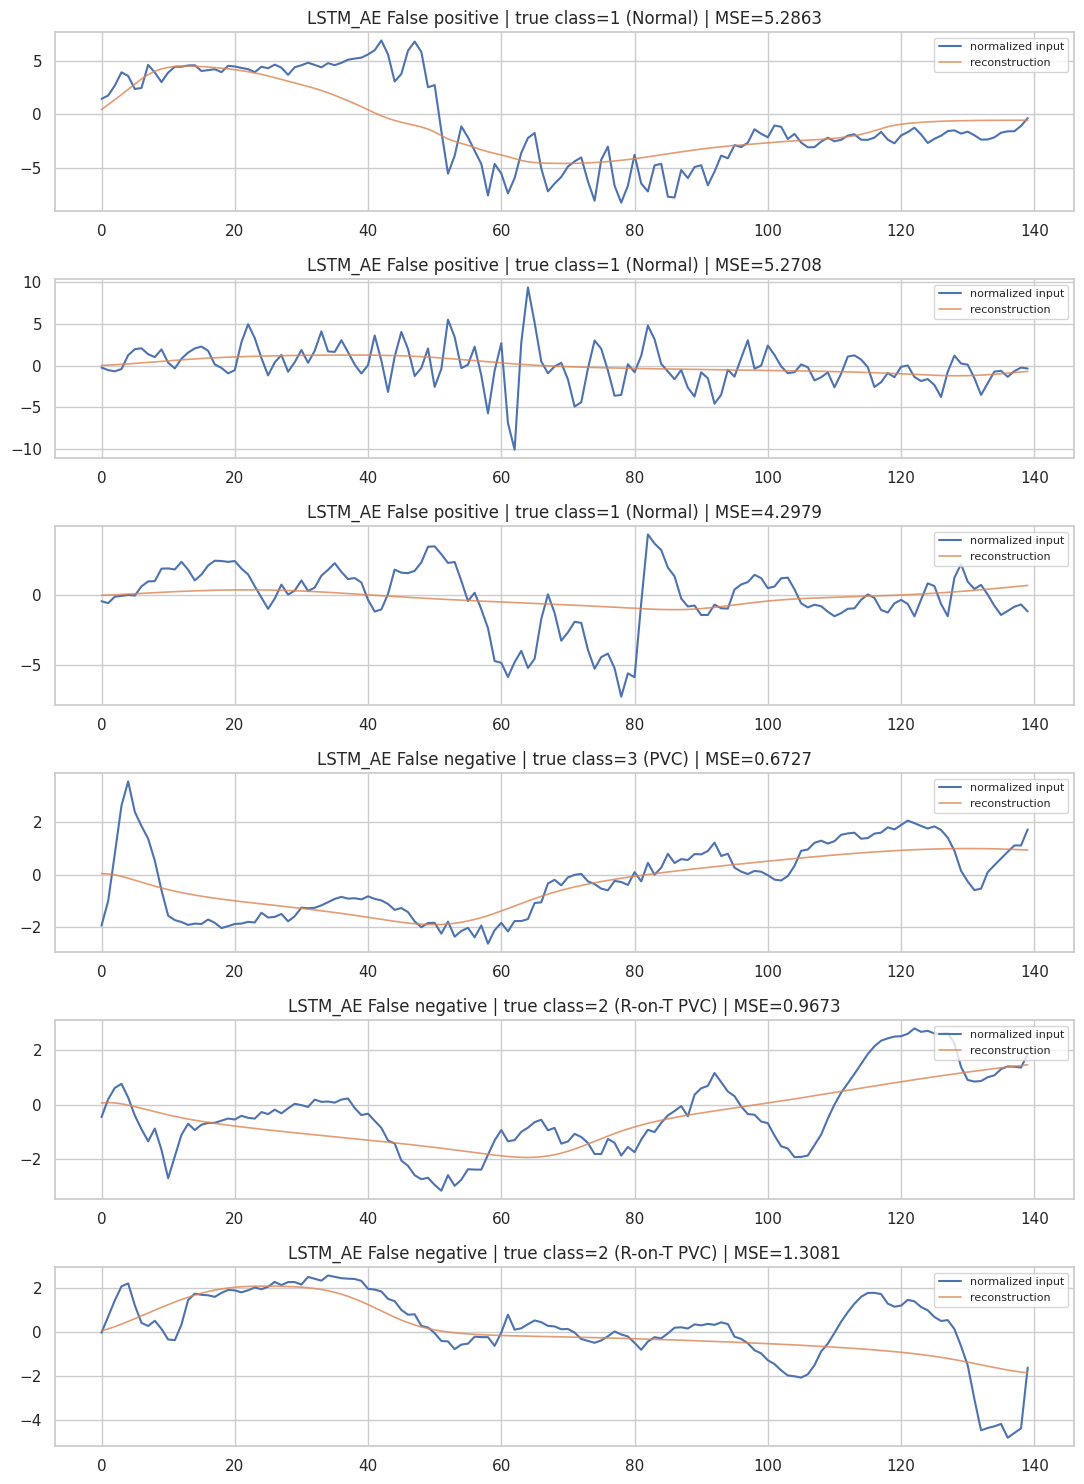

In [ ]:
def plot_failure_cases(name, n_each=3):
    model = models[name]
    threshold = thresholds[name]['calibration_f1']
    pred = scores[name]['final'] > threshold
    fp = np.flatnonzero((y_final == 0) & pred)
    fn = np.flatnonzero((y_final == 1) & ~pred)
    # Most confident errors: highest-score FPs and lowest-score FNs.
    fp = fp[np.argsort(scores[name]['final'][fp])[::-1]][:n_each]
    fn = fn[np.argsort(scores[name]['final'][fn])][:n_each]
    chosen = [('False positive', i) for i in fp] + [('False negative', i) for i in fn]
    if not chosen:
        print(name, ': no failure cases at this threshold.'); return
    recon = model.predict(X_final_seq[[i for _, i in chosen]], verbose=0).squeeze(-1)
    fig, axes = plt.subplots(len(chosen), 1, figsize=(11, 2.5 * len(chosen)), squeeze=False)
    for ax, ((kind, i), reconstructed) in zip(axes[:, 0], zip(chosen, recon)):
        ax.plot(X_final[i], label='normalized input', linewidth=1.5)
        ax.plot(reconstructed, label='reconstruction', linewidth=1.2, alpha=.8)
        ax.set_title(f'{name} {kind} | true class={class_final[i]} ({class_names[class_final[i]]}) | MSE={scores[name]["final"][i]:.4f}')
        ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout(); plt.savefig(FIG_DIR / f'{name}_failure_cases.png', dpi=160, bbox_inches='tight'); plt.show()

for name in models:
    plot_failure_cases(name)


## Stretch baselines: One-Class SVM and Isolation Forest

Both baselines are fit on the identical normalized normal-training matrix. Their anomaly scores are oriented so larger values indicate greater abnormality. To keep the baseline comparison leakage-safe and concise, each baseline uses an F1-optimized threshold from the same labeled calibration subset; final labels remain unused until scoring. These are reference models, not part of the required neural architecture comparison.

In [ ]:
baseline_models = {
    'OneClassSVM': OneClassSVM(kernel='rbf', gamma='scale', nu=0.05),
    'IsolationForest': IsolationForest(n_estimators=150 if FAST_MODE else 300,
                                       contamination='auto', random_state=SEED, n_jobs=-1),
}
baseline_rows, baseline_thresholds = [], {}
for name, model in baseline_models.items():
    started = time.perf_counter(); model.fit(X_train_n); elapsed = time.perf_counter() - started
    calibration_scores = -model.decision_function(X_calib)
    final_scores = -model.decision_function(X_final)
    threshold, calibration_f1 = f1_optimal_threshold(y_calib, calibration_scores)
    baseline_thresholds[name] = threshold
    row = metric_row(name, 'calibration_f1', y_final, final_scores, threshold)
    row.update({'parameters': np.nan, 'train_seconds': elapsed, 'calibration_f1': calibration_f1})
    baseline_rows.append(row)
baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results.round(4))
baseline_results.to_csv(OUTPUT_DIR / 'baseline_final_metrics.csv', index=False)


,model,threshold_rule,threshold,precision,recall,specificity,balanced_accuracy,f1,average_precision,roc_auc,tn,fp,fn,tp,parameters,train_seconds,calibration_f1
0,OneClassSVM,calibration_f1,0.4374,0.9516,0.9928,0.9640,0.9784,0.9718,0.9477,0.9859,563,21,3,413,NaN,0.0345,0.9593
1,IsolationForest,calibration_f1,-0.0072,0.9009,0.9832,0.9229,0.9531,0.9402,0.8664,0.9620,539,45,7,409,NaN,0.7730,0.9314


## Controlled comparison and required discussion questions

### Question 1 — Which autoencoder is preferable, and why?
Use the table generated below rather than assuming a winner. Compare final-test F1 under the **same threshold rule**, then inspect precision/recall, average precision, parameter count, runtime, class-specific recall, and failures. If Conv1D leads, a plausible explanation is that ECG abnormalities are captured effectively by local shift-tolerant motifs and convolution is computationally efficient. If LSTM leads, a plausible explanation is that ordered long-range context improves reconstruction discrimination. If results are close, prefer the smaller/faster model unless a particular anomaly type is clinically or operationally more important. These are interpretations to test against observed outputs, not pre-run claims.

### Question 2 — Which threshold strategy is preferable?
The labeled-calibration threshold directly optimizes F1 and is preferable when representative labeled anomalies and the deployment class balance are available. The normal-validation P95 rule avoids anomaly-label dependence and is preferable for genuinely unsupervised deployment, but its nominal 5% validation tail does not guarantee a 5% false-positive rate after distribution shift. Compare both rows per model. A large test advantage for calibration supports using labels; instability across anomaly types or a large calibration-to-test change warns that threshold tuning may have overfit. Thresholds should be recalibrated after material sensor, population, preprocessing, or prevalence changes.

In [ ]:
# Controlled autoencoder table: same data, training protocol, score, and threshold policies
comparison = results.copy()
comparison['parameters'] = comparison['model'].map({k: v.count_params() for k, v in models.items()})
comparison['train_seconds'] = comparison['model'].map(train_seconds)
comparison['epochs_ran'] = comparison['model'].map({k: len(v.history['loss']) for k, v in histories.items()})
ordered = ['model', 'threshold_rule', 'parameters', 'train_seconds', 'epochs_ran',
           'threshold', 'precision', 'recall', 'specificity', 'balanced_accuracy',
           'f1', 'average_precision', 'roc_auc', 'tn', 'fp', 'fn', 'tp']
comparison = comparison[ordered].sort_values(['threshold_rule', 'f1'], ascending=[True, False])
display(comparison.round(4).style.highlight_max(
    subset=['precision', 'recall', 'specificity', 'balanced_accuracy', 'f1',
            'average_precision', 'roc_auc'], color='#b7e4c7'))
comparison.to_csv(OUTPUT_DIR / 'controlled_autoencoder_comparison.csv', index=False)

all_methods = pd.concat([comparison, baseline_results], ignore_index=True, sort=False)
all_methods.to_csv(OUTPUT_DIR / 'all_methods_comparison.csv', index=False)


,model,threshold_rule,parameters,train_seconds,epochs_ran,threshold,precision,recall,specificity,balanced_accuracy,f1,average_precision,roc_auc,tn,fp,fn,tp
3,LSTM_AE,calibration_f1,28273,53.011000,60,1.523500,0.966600,0.973600,0.976000,0.974800,0.970100,0.961600,0.987700,570,14,11,405
1,Conv1D_AE,calibration_f1,7841,23.955000,60,0.014800,0.715100,0.959100,0.727700,0.843400,0.819300,0.714100,0.877300,425,159,17,399
2,LSTM_AE,normal_val_p95,28273,53.011000,60,1.190200,0.936700,0.995200,0.952100,0.973600,0.965000,0.961600,0.987700,556,28,2,414
0,Conv1D_AE,normal_val_p95,7841,23.955000,60,0.028800,0.717400,0.238000,0.933200,0.585600,0.357400,0.714100,0.877300,545,39,317,99


## Limitations

- ECG5000 contains short, pre-segmented and preprocessed beats; results may not transfer to continuous, noisy, multi-lead, or differently sampled ECG.
- Reconstruction error is not guaranteed to be larger for every anomaly: expressive autoencoders can reconstruct abnormal inputs, causing false negatives.
- F1 depends on anomaly prevalence and values precision/recall equally. A deployment may require sensitivity constraints, cost-weighted thresholds, patient-level grouping, or calibrated alert rates instead.
- The random stratified split operates at beat level because patient identifiers are unavailable here. If multiple beats belong to one patient, patient-level leakage cannot be ruled out; a patient-grouped external evaluation would be stronger.
- One split and one seed do not quantify uncertainty. Repeated grouped splits or bootstrap confidence intervals are appropriate follow-up work, but must preserve a genuinely untouched evaluation set.
- Parameter counts are reported, but the architectures are controlled by protocol rather than exactly capacity-matched. A broader, compute-matched hyperparameter study could refine the architecture conclusion.
- The per-class labels describe morphology categories in the dataset, not a validated clinical diagnosis. This notebook is educational and not a medical device.

In [ ]:
# Persist reproducibility metadata, scaler statistics, final scores, and a ZIP archive
config = {
    'seed': SEED, 'fast_mode': FAST_MODE, 'epochs_max': EPOCHS,
    'batch_size': BATCH_SIZE, 'early_stopping_patience': PATIENCE,
    'normal_label': 1, 'anomaly_labels': [2, 3, 4, 5],
    'final_test_fraction': 0.20, 'calibration_fraction_of_development': 0.20,
    'normal_validation_fraction': 0.20, 'tensorflow_version': tf.__version__,
    'gpu_devices': [device.name for device in tf.config.list_physical_devices('GPU')],
    'dataset_loader': 'aeon.datasets.load_classification',
    'dataset_name': 'ECG5000', 'dataset_split': None,
    'aeon_version': aeon.__version__, 'thresholds': thresholds,
    'model_architectures': {
        name: {'parameter_count': int(model.count_params()),
               'keras_architecture': json.loads(model.to_json())}
        for name, model in models.items()
    },
    'report_artifacts': {
        'controlled_comparison_csv': 'controlled_autoencoder_comparison.csv',
        'all_methods_comparison_csv': 'all_methods_comparison.csv',
        'split_summary_csv': 'split_summary.csv',
        'threshold_calibration_figure': 'figures/threshold_calibration.png',
        'combined_final_distributions_confusions_figure': 'figures/final_distributions_confusions.png',
        'final_pr_curves_figure': 'figures/final_pr_curves.png',
        'per_anomaly_type_figure': 'figures/per_anomaly_type_recall.png',
    },
}
with open(OUTPUT_DIR / 'config.json', 'w') as handle:
    json.dump(config, handle, indent=2)
np.savez(OUTPUT_DIR / 'normal_train_scaler.npz', mean=scaler.mean_, scale=scaler.scale_, var=scaler.var_)

score_export = pd.DataFrame({'source_index': final_idx, 'original_class': class_final,
                                 'is_anomaly': y_final})
for name in models:
    score_export[f'{name}_mse'] = scores[name]['final']
    for rule, threshold in thresholds[name].items():
        score_export[f'{name}_{rule}_prediction'] = (scores[name]['final'] > threshold).astype(int)
score_export.to_csv(OUTPUT_DIR / 'final_test_scores_predictions.csv', index=False)

archive_path = shutil.make_archive('/content/ecg_ae_outputs', 'zip', root_dir=OUTPUT_DIR)
print('Saved artifacts to:', OUTPUT_DIR)
print('ZIP archive:', archive_path, '| size MB:', round(Path(archive_path).stat().st_size / 1e6, 2))
print('Files:')
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file(): print(' -', path.relative_to(OUTPUT_DIR))


Saved artifacts to: /content/ecg_ae_outputs
ZIP archive: /content/ecg_ae_outputs.zip | size MB: 2.53
Files:
 - all_methods_comparison.csv
 - autoencoder_final_metrics.csv
 - baseline_final_metrics.csv
 - config.json
 - controlled_autoencoder_comparison.csv
 - figures/Conv1D_AE_failure_cases.png
 - figures/LSTM_AE_failure_cases.png
 - figures/eda_distribution_waveforms.png
 - figures/final_distributions_confusions.png
 - figures/final_pr_curves.png
 - figures/per_anomaly_type_recall.png
 - figures/threshold_calibration.png
 - figures/training_curves.png
 - final_test_scores_predictions.csv
 - models/Conv1D_AE_best.keras
 - models/Conv1D_AE_final.keras
 - models/LSTM_AE_best.keras
 - models/LSTM_AE_final.keras
 - normal_train_scaler.npz
 - per_anomaly_type_results.csv
 - split_summary.csv
 - thresholds.json
